In [1]:
pip install pandas numpy matplotlib opencv-python


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


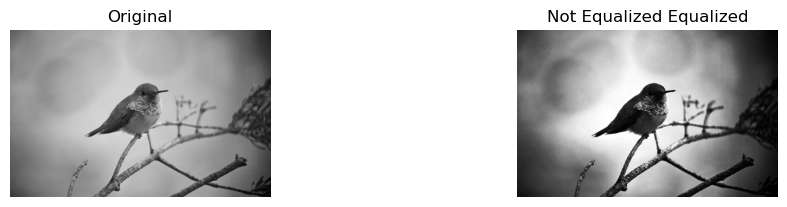

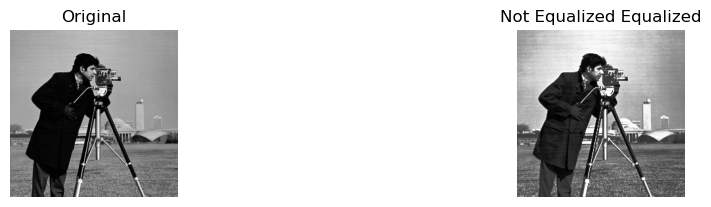

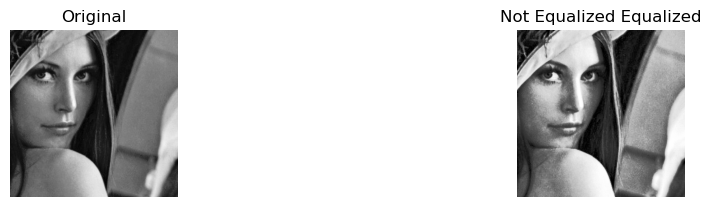

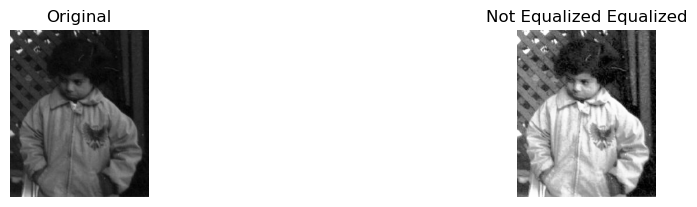

In [2]:
import pandas as pd
import numpy as np
import  cv2
import matplotlib.pyplot as plt
import os
input_folder = r"C:\Users\admin\Documents\IPMV\EXP 2\Dull_images"
output_folder = r"C:\Users\admin\Documents\IPMV\EXP 2\HE"

extensions =( '.tif', '.tiff', '.png', '.jpeg', '.jpg', '.bmp', '.png')

for file in os.listdir(input_folder):
    path = os.path.join(input_folder, file)
    I = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

    I_he = cv2.equalizeHist(I)
    
    plt.figure(figsize=(12,10))
    
    plt.subplot(4,2,1)
    plt.imshow(I, cmap="gray")
    plt.title("Original")
    plt.axis('off')
    
    plt.subplot(4,2,2)
    plt.imshow(I_he, cmap="gray")
    plt.title("Not Equalized Equalized")
    plt.axis('off')


    cv2.imwrite(os.path.join(output_folder, 'HE_' + file), I_he)

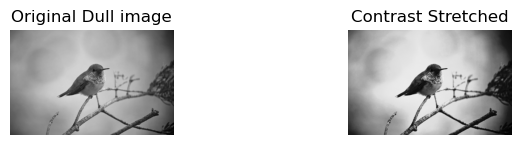

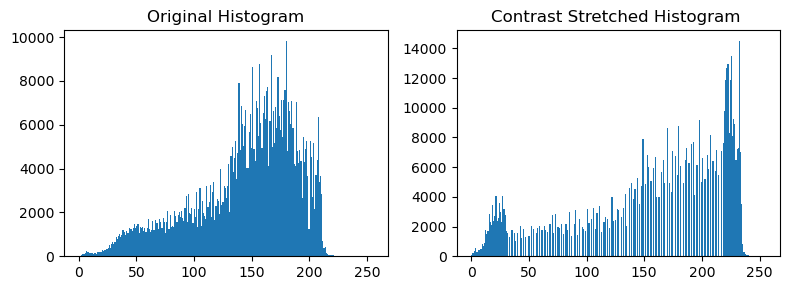

In [4]:
image_path=r"C:\Users\admin\Documents\IPMV\EXP 2\Dull_images\bird.png"
I1=  cv2.imread(image_path,cv2.IMREAD_GRAYSCALE) 
I_f= I1.astype(np.float32) 

r1,r2=70,180 
s1,s2=30,220 

m1=s1/r1 
m2=(s2-s1)/(r2-r1) 
m3=(255-s2)/(255-r2) 
I_cs=np.zeros_like(I_f) 

mask1=I_f<=r1 
mask2=(I_f>r1)&(I_f<=r2) 
mask3=I_f>r2 

I_cs[mask1]=m1*I_f[mask1]
I_cs[mask2]=s1 + m2 * (I_f[mask2] - r1)
I_cs[mask3]=s2 + m3 * (I_f[mask3] - r2)

plt.figure(figsize=(8,3))

plt.subplot(2,2,1)
plt.imshow(I1, cmap="gray")
plt.title("Original Dull image")
plt.axis('off')

plt.subplot(2,2,2)
plt.imshow(I_cs, cmap="gray")
plt.title("Contrast Stretched")
plt.axis('off')
plt.show()

plt.figure(figsize=(8,3))
plt.subplot(1,2,1)
plt.hist(I1.ravel(), bins=256, range=(0,255))
plt.title("Original Histogram")

plt.subplot(1,2,2)
plt.hist(I_cs.ravel(), bins=256, range=(0,255))
plt.title("Contrast Stretched Histogram ")
plt.tight_layout()
plt.show()


